# FINAL PORTFOLIO: CLASSIFICATION TASK
# Dataset: Road Accident Data
# Target: Urban_or_Rural_Area

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# STEP 1: EDA AND DATA UNDERSTANDING

In [ ]:
# Load dataset
df_acc = pd.read_csv('Road Accident Data.csv')

In [ ]:
# Selecting features mentioned in the proposal
class_cols = ['Speed_limit', 'Light_Conditions', 'Weather_Conditions', 'Road_Type', 'Day_of_Week', 'Urban_or_Rural_Area']
df_class = df_acc[class_cols].dropna()

In [ ]:
# To make code run fast for the assignment, we use a sample
df_class = df_class.sample(n=10000, random_state=42)

In [ ]:
# Encoding (Converting words to numbers)
le = LabelEncoder()
for col in ['Light_Conditions', 'Weather_Conditions', 'Road_Type', 'Day_of_Week', 'Urban_or_Rural_Area']:
    df_class[col] = le.fit_transform(df_class[col])

In [ ]:
# Summary Statistics
print("Data Summary:")
print(df.describe())

Data Summary:
         Speed_limit  Light_Conditions  Urban_or_Rural_Area  \
count  301916.000000     301916.000000        301916.000000   
mean       38.916487          3.320371             0.643500   
std        14.057757          1.221030             0.478966   
min        10.000000          0.000000             0.000000   
25%        30.000000          3.000000             0.000000   
50%        30.000000          4.000000             1.000000   
75%        50.000000          4.000000             1.000000   
max        70.000000          4.000000             1.000000   

       Weather_Conditions  Accident_Severity  
count       301916.000000      301916.000000  
mean             1.655666           2.828131  
std              1.509206           0.468167  
min              0.000000           0.000000  
25%              1.000000           3.000000  
50%              1.000000           3.000000  
75%              1.000000           3.000000  
max              7.000000           3.0000

/tmp/ipython-input-374649044.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Urban_or_Rural_Area', data=df_class, palette='viridis')


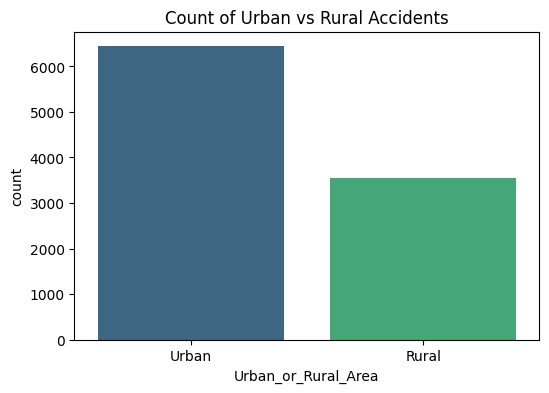

In [ ]:
# Visual 1: Target Variable Count
plt.figure(figsize=(6,4))
sns.countplot(x='Urban_or_Rural_Area', data=df_class, palette='viridis')
plt.title('Count of Urban vs Rural Accidents')
plt.show()

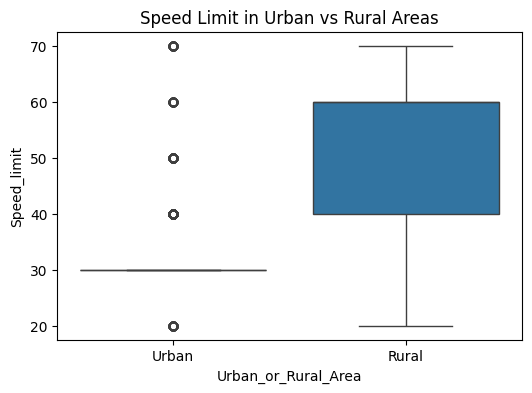

In [ ]:
# Visual 2: Speed Limit vs Area
plt.figure(figsize=(6,4))
sns.boxplot(x='Urban_or_Rural_Area', y='Speed_limit', data=df_class)
plt.title('Speed Limit in Urban vs Rural Areas')
plt.show()

# STEP 2: NEURAL NETWORK (MLP CLASSIFIER)

In [ ]:
X = df_class.drop('Urban_or_Rural_Area', axis=1)
y = df_class['Urban_or_Rural_Area']

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Scale data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
## 1. Use the model to predict the results for our test data
y_pred = mlp_clf.predict(X_test_scaled)

# 2. Calculate the Accuracy Score
accuracy = accuracy_score(y_test, y_pred)

# 3. Print the results in a clear way
print("--- MLP Classifier Results ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")

print("\nDetailed Classification Report:")
# This shows Precision, Recall, and F1-Score
print(classification_report(y_test, y_pred))

# 4. Show the Confusion Matrix
# It shows exactly where the model got confused
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

--- MLP Classifier Results ---
Overall Accuracy: 85.40%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77       715
           1       0.84      0.95      0.89      1285

    accuracy                           0.85      2000
   macro avg       0.86      0.81      0.83      2000
weighted avg       0.86      0.85      0.85      2000

Confusion Matrix:
[[ 484  231]
 [  61 1224]]


In [ ]:
# Evaluation
mlp_pred = mlp_clf.predict(X_test_scaled)
print("--- Neural Network (MLP) Accuracy ---")
print(accuracy_score(y_test, mlp_pred))

--- Neural Network (MLP) Accuracy ---
0.854


# STEP 3: CLASSICAL MODELS

In [ ]:
# Model 1: Logistic Regression
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
log_pred = log_reg.predict(X_test)

In [ ]:
# Model 2: Decision Tree
dt_clf = DecisionTreeClassifier(random_state=42)
dt_clf.fit(X_train, y_train)
dt_pred = dt_clf.predict(X_test)

In [ ]:
print("\n--- Classical Models Accuracy ---")
print("Logistic Regression:", accuracy_score(y_test, log_pred))
print("Decision Tree:", accuracy_score(y_test, dt_pred))


--- Classical Models Accuracy ---
Logistic Regression: 0.8505
Decision Tree: 0.8515


# STEP 4: HYPERPARAMETER OPTIMIZATION

In [ ]:
# Tuning Decision Tree
param_grid = {'max_depth': [3, 5, 10], 'criterion': ['gini', 'entropy']}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=3)
grid_search.fit(X_train, y_train)

print("\nBest Parameters for Decision Tree:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)


Best Parameters for Decision Tree: {'criterion': 'entropy', 'max_depth': 5}
Best CV Score: 0.8603749643822654


# STEP 5: FEATURE SELECTION (Filter Method)

In [ ]:
# Using Chi-Square to pick top 3 features
selector = SelectKBest(score_func=chi2, k=3)
X_train_new = selector.fit_transform(X_train, y_train)
X_test_new = selector.transform(X_test)

In [ ]:
selected_features = X.columns[selector.get_support()]
print("\nSelected Features:", list(selected_features))


Selected Features: ['Speed_limit', 'Weather_Conditions', 'Road_Type']


# STEP 6: FINAL MODELS COMPARISON

In [ ]:
# Final Decision Tree with best settings and features
final_model = DecisionTreeClassifier(max_depth=5, criterion='entropy', random_state=42)
final_model.fit(X_train_new, y_train)
final_pred = final_model.predict(X_test_new)

In [ ]:
print("\n--- Final Model Report ---")
print(classification_report(y_test, final_pred))


--- Final Model Report ---
              precision    recall  f1-score   support

           0       0.86      0.71      0.78       715
           1       0.85      0.93      0.89      1285

    accuracy                           0.85      2000
   macro avg       0.85      0.82      0.83      2000
weighted avg       0.85      0.85      0.85      2000

